In [2]:
import numpy as np
from tqdm import tqdm, trange
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader

from torchvision.transforms import ToTensor
from torchvision.datasets.mnist import MNIST

np.random.seed(0)
torch.manual_seed(0)

In [3]:
def main():
    transform = ToTensor()
    train_set = MNIST(root='./../datasets', train=True, download=True, transform=transform)
    test_set = MNIST(root='./../datasets', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_set, shuffle=True, batch_size=128)
    test_loader = DataLoader(test_set, shuffle=False, batch_size=128)

    device =  torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device: ",device, f"({torch.cuda.get_device_name(device)})" if torch.cuda.is_available() else "")
    model = MyViT((1,28,28), n_patches=7, n_blocks=2, hidden_d=8, n_heads=2, out_d=10).to(device)
    N_EPOCHS=5
    LR = 0.005

    #Training loop
    optimizer =Adam(model.parameters(), lr=LR)
    criterion = CrossEntropyLoss()
    for epoch in trange(N_EPOCHS, desc="Training"):
        train_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} in training", leave=False):
            x,y = batch
            x,y = x.to(device), y.to(device)
            y_hat = model(x)
            loss = criterion(y_hat, y)

            train_loss += loss.detach().cpu().item()/len(train_loader)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch +1}/{N_EPOCHS} loss: {train_loss:.2f}")

    with torch.no_grad():
        correct, total =0,0
        test_loss = 0.0
        for batch in tqdm(test_loader, desc="Testing"):
            x,y = batch
            x, y = x.to(device), y.to(device)
            y_hat = model(x)
            loss = criterion(y_hat,y)
            test_loss += loss.detach().cpu().item() / len(test_loader)

            correct += torch.sum(torch.argmax(y_hat, dim=1)==y).detach().cpu().item()
            total+= len(x)
        print(f"Test loss: {test_loss: .2f}")
        print(f"Test accuracy: {correct / total *100: .2f}%")

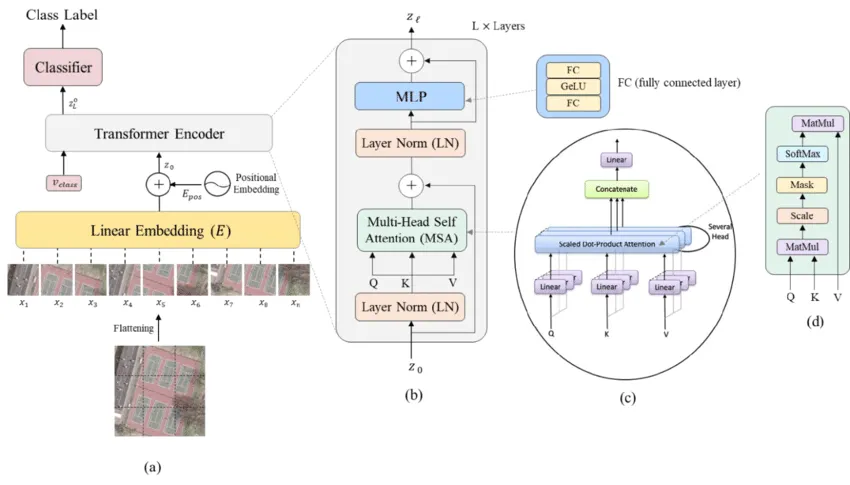

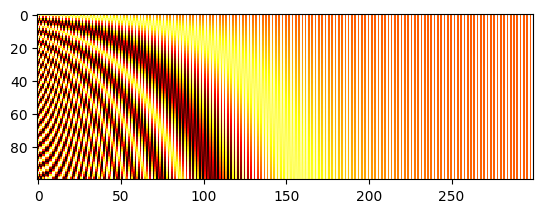

In [4]:
def get_positional_embeddings(sequence_length,d):
    result = torch.ones(sequence_length,d)
    for i in range(sequence_length):
        for j in range(d):
            result[i][j] = np.sin(i/(10000 **(j/d))) if j%2==0 else np.cos(i/(10000 **((j-1)/(d))))
    return result
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    plt.imshow(get_positional_embeddings(100,300), cmap = "hot", interpolation="nearest")
    plt.show()

In [ ]:
class MyViT(nn.Module):
    def __init__(self, chw=(1,28,28), n_patches=7):
        #super constructor
        super(MyViT, self).__init__()
        #Attributes
        self.chw = chw # (C,H,W)
        self.n_patches = n_patches

        assert chw[1] % n_patches ==0, "Input shape not entirely divisible by number of patches"
        assert chw[2] % n_patches ==0, "Input shape not entirely divisible by number of patches"
        self.patch_size = (chw[1]/ n_patches, chw[2]/n_patches)
        #linear mapper
        self.input_d = int(chw[0]*self.patch_size[0]* self.patch_size[1])
        self.linear_mapper = nn.Linear(self.input_d, self.hidden_d)
        #2 learnable classifiation token
        self.class_token = nn.Parameter(torch.rand(1,self.hidden_d))
        #3 positional embedding
        self.pos_embed = nn.Parameter(torch.tensor(get_positional_embeddings(self.n_patches**2+1, self.hidden_d)))
        self.pos_embed.requires_grad = False

    def forward(self, images):
        patches = patchify(images, self.n_patches)
        tokens = self.linear_mapper(patches)
        tokens = torch.stack([torch.vstack((self.class_token, tokens[i])) for i in range(len(tokens))])

        #adding positional embedding
        pos_embed = self.pos_embed.repeat(n,1,1)
        out = tokens+pos_embed
        return patches

In [6]:
def patchify(images, n_patches):
    n,c,h, w = images.shape
    assert h==w, "Patchify method is implemented for square images only"
    patches = torch.zeros(n, n_patches **2, h*w*c // n_patches **2)
    patch_size = h// n_patches
    for idx, image in enumerate(images):
        for i in range(n_patches):
            for j in range(n_patches):
                patch = image[:,  i*patch_size : (i+1)*patch_size, j*patch_size :(j+1)*patch_size]
                patches[idx, i*n_patches+j] = patch.flatten()
    return patches

In [14]:
if __name__ == '__main__':
    model = MyViT(chw=(1,28,28), n_patches=7)
    x =torch.randn(7,1,28,28) 
    print(model(x).shape)

AttributeError: 'MyViT' object has no attribute 'hidden_d'